# Customer Segmentation: RFM-Based Analysis & K-Means Clustering
**Project Data Science: Customer Analytics & Behavioral Segmentation**

---

## 1. Latar Belakang & Tujuan Bisnis
Dataset ini mencatat seluruh transaksi pembelian dari perusahaan *online retail* berbasis di Inggris (United Kingdom) selama rentang waktu 1 tahun (Desember 2010 – Desember 2011). 

Tujuan utama dari proyek ini adalah:
1. **Memahami perilaku transaksi pelanggan** melalui analisis eksploratif mendalam (EDA).
2. **Mengekstraksi metrik RFM murni (Recency, Frequency, Monetary)** untuk setiap pelanggan unik.
3. **Merumuskan strategi promosi dan retensi yang relevan** untuk setiap segmen pelanggan guna meningkatkan *Customer Lifetime Value* (CLV) dan menekan angka *churn*.
4. **Menganalisis segmen internasional (Non-UK)** secara terfokus setelah mengisolasi anomali/outlier transaksi menggunakan *Isolation Forest*.

> 📚 **Sumber Data:** [Online Retail Dataset - Kaggle / UCI Machine Learning Repository](https://www.kaggle.com/vijayuv/onlineretail)

In [ ]:
# Package imports
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
import os

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Style configuration
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Custom modular visualization utilities
from utils.custom_chart import plot_pie_chart, plot_bar_chart, plot_line_chart

## 2. Eksplorasi & Pembersihan Data Awal (*Data Preparation & Cleansing*)

Pada tahap ini, data transaksi dimuat dari file lokal `dataset/Online Retail.xlsx` (atau diunduh otomatis bila belum tersedia). Dilakukan pengecekan struktur tipe data, penanganan nilai hilang (*missing values*), serta pembersihan anomali kuantitas negatif (*cancellations*) dan harga satuan nol.

In [17]:
# Load data lokal dari folder 'dataset' jika tersedia, atau unduh otomatis
local_path = os.path.join('dataset', 'Online Retail.xlsx')
if os.path.exists(local_path):
    df = pd.read_excel(local_path)
else:
    df = pd.read_excel('https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx')

df_backup = df.copy()
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [19]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Pembersihan Missing Values pada `CustomerID`
Karena fokus analisis adalah segmentasi pelanggan, setiap baris transaksi wajib memiliki identitas pelanggan (`CustomerID`). Transaksi tanpa `CustomerID` (~24.9% dari total data) tidak dapat diatribusikan ke profil pelanggan tertentu sehingga perlu dieliminasi.

In [20]:
# Check missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [21]:
# Remove missing values
df = df[df['CustomerID'].notna()]
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Penanganan Nilai Anomali (`Quantity <= 0` & `UnitPrice <= 0`)
Pada data e-commerce ini terdapat nilai kuantitas negatif (mencerminkan pembatalan/retur transaksi) serta harga satuan bernilai 0 (produk bonus/kesalahan input). Data anomali ini difilter agar tidak mendistorsi perhitungan moneter dan frekuensi belanja.

In [22]:
# Check anomaly data
quantity_zero = len(df[df["Quantity"] <= 0])
perc_quantity_zero = (quantity_zero / len(df)) * 100
unitprice_zero = len(df[df["UnitPrice"] == 0])
perc_unitprice_zero = (unitprice_zero / len(df)) * 100

print(f"Transaksi Quantity <= 0: {quantity_zero:,} ({perc_quantity_zero:.2f}%)")
print(f"Transaksi UnitPrice == 0: {unitprice_zero:,} ({perc_unitprice_zero:.2f}%)")

Transaksi Quantity <= 0: 8,905 (2.19%)
Transaksi UnitPrice == 0: 40 (0.01%)


In [23]:
# Remove anomaly records
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,397884.000000,397884.000000
mean,12.988238,3.116488
std,179.331775,22.097877
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


### Ringkasan Data Pasca Pembersihan
Data bersih kini memuat **397,884 baris transaksi valid** dari **4,338 pelanggan unik** yang siap dianalisis.

In [24]:
df[['InvoiceNo', 'StockCode', 'CustomerID', 'Country']].nunique()

InvoiceNo     18532
StockCode      3665
CustomerID     4338
Country          37
dtype: int64

### Proporsi Asal Negara Pelanggan (UK vs Non-UK)
Retailer ini berbasis di Inggris. Dari 37 negara asal pelanggan, mayoritas transaksi berasal dari United Kingdom. Untuk analisis makro, negara dikelompokkan menjadi **UK** dan **Non-UK**.

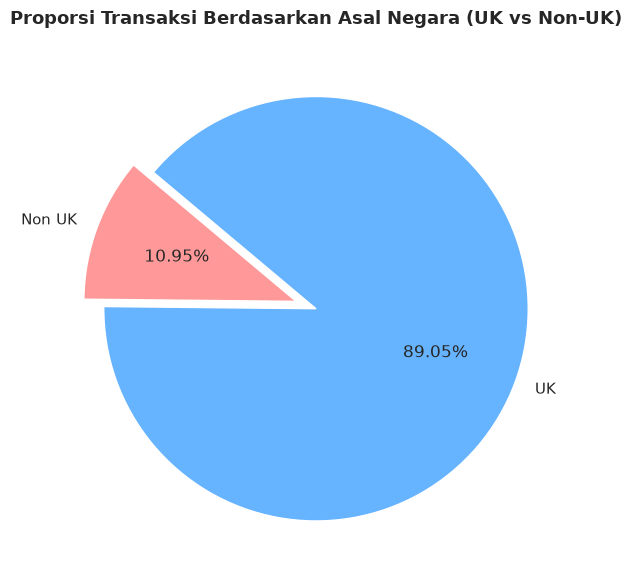

In [25]:
# Simplify country origin & visualisasi proporsi
df['Country_isUK'] = np.where(df['Country']=='United Kingdom', 'UK', 'Non UK')
customers_origin = df.groupby(['Country_isUK']).size()

plot_pie_chart(
    data=customers_origin,
    title='Proporsi Transaksi Berdasarkan Asal Negara (UK vs Non-UK)',
    labels=customers_origin.index,
    autopct='%1.2f%%',
    startangle=140,
    colors=['#ff9999', '#66b3ff'],
    explode=(0.1, 0)
)

### 📊 Customer Origin Proportion
- **Basis Domestik Sangat Dominan:** Sekitar **89,05% transaksi** (354.321 transaksi) berasal dari pasar domestik (**United Kingdom**), sedangkan pelanggan internasional (**Non-UK**) menyumbang **10,95% transaksi** (43.563 transaksi).
- **Sebaran Pelanggan Unik:** Dari total 4.338 pelanggan, 3.920 pelanggan (**90,4%**) berasal dari UK dan 418 pelanggan (**9,6%**) berasal dari luar UK. Keberadaan pelanggan internasional ini membuka peluang strategis untuk ekspansi pasar global (*cross-border eCommerce*).

### Analisis Tren Pembelian (Weekly & Monthly Revenue Trend)
Fitur `TotalAmount` dihitung dari perkalian `Quantity` $\times$ `UnitPrice`, dan kolom `InvoiceDate` dikonversi ke format datetime untuk melihat tren transaksi mingguan dan bulanan.

In [26]:
# Create TotalAmount & cast datetime
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Country_isUK,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,UK,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,UK,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,UK,20.34


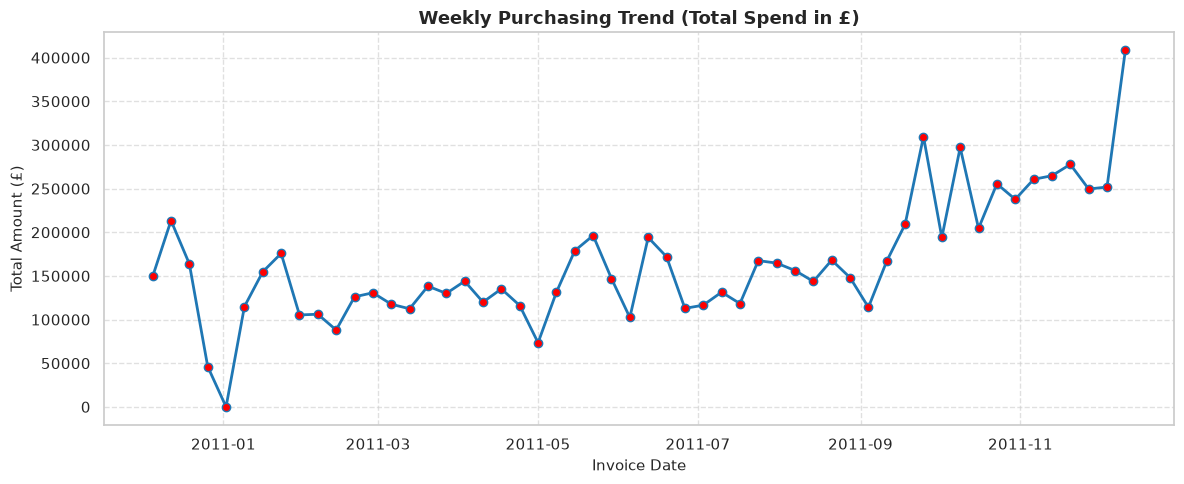

<Axes: title={'center': 'Weekly Purchasing Trend (Total Spend in £)'}, xlabel='Invoice Date', ylabel='Total Amount (£)'>

In [27]:
# Plot weekly purchasing trend
weekly_purchasements = df.copy()
weekly_purchasements = weekly_purchasements.groupby(by=pd.Grouper(key="InvoiceDate", freq="1W"))["TotalAmount"].sum()

plot_line_chart(
    x=weekly_purchasements.index,
    y=weekly_purchasements.values,
    title='Weekly Purchasing Trend (Total Spend in £)',
    xlabel='Invoice Date',
    ylabel='Total Amount (£)',
)

### 📈 Weekly Purchasing Trend
- **Pola Pembelian Konsisten & Lonjakan Q4:** Total transaksi mingguan berada pada rentang interkuartil stabil antara **£117.000 hingga £195.000** pada Q1 sampai Q3, kemudian mengalami lonjakan eksponensial di Q4 mencapai puncaknya hingga **£408.000+ per minggu** pada pergantian bulan November–Desember (pekan ke-49).
- **Kesiapan Logistik Musiman:** Lonjakan ini merupakan siklus tahunan persiapan Natal dan festival belanja akhir tahun (*holiday shopping season*).

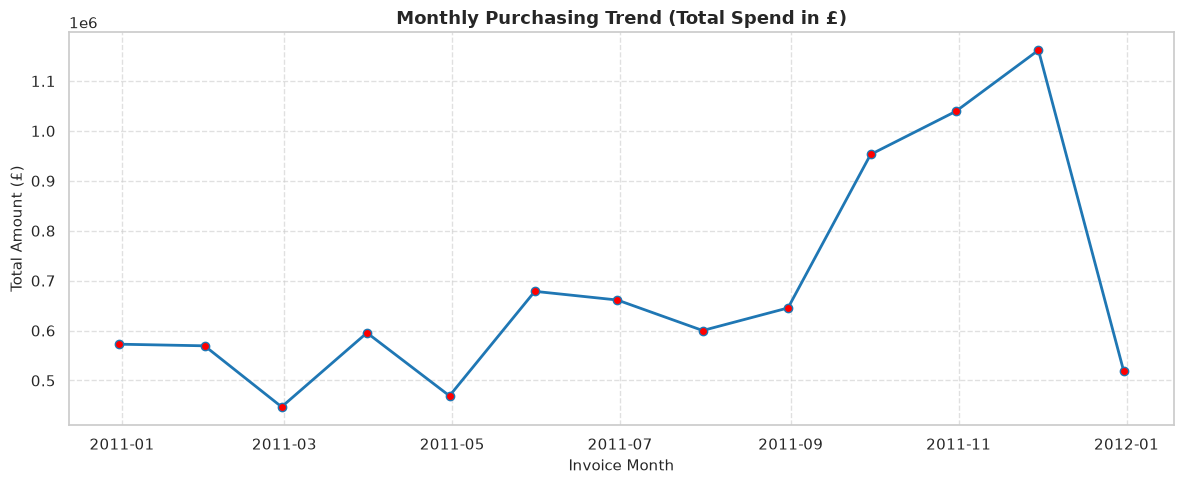

<Axes: title={'center': 'Monthly Purchasing Trend (Total Spend in £)'}, xlabel='Invoice Month', ylabel='Total Amount (£)'>

In [28]:
# Plot monthly purchasing trend
monthly_purchasements = df.copy()
monthly_purchasements = monthly_purchasements.groupby(by=pd.Grouper(key="InvoiceDate", freq="ME"))["TotalAmount"].sum()

plot_line_chart(
    x=monthly_purchasements.index,
    y=monthly_purchasements.values,
    title='Monthly Purchasing Trend (Total Spend in £)',
    xlabel='Invoice Month',
    ylabel='Total Amount (£)'
)

### 📅 Monthly Purchasing Trend
- **Puncak Penjualan November:** Pendapatan bulanan memuncak secara rekor pada **November 2011** melampaui **£1,1 juta**.
- **Penurunan di Desember:** Penurunan nilai di bulan Desember disebabkan data transaksi hanya tercatat hingga tanggal 9 Desember 2011.

## 3. Feature Engineering: Metrik RFM (Recency, Frequency, Monetary)

Analisis RFM merupakan kerangka segmentasi perilaku pelanggan (*behavioral customer segmentation*):
* **Recency (R):** Jumlah hari sejak transaksi terakhir pelanggan hingga tanggal referensi data terakhir. Nilai rendah menandakan pelanggan aktif baru saja berbelanja.
* **Frequency (F):** Jumlah total transaksi/order yang dilakukan oleh pelanggan. Nilai tinggi menunjukkan loyalitas dan keterikatan tinggi.
* **Monetary (M):** Total nilai uang yang dibelanjakan pelanggan selama periode pengamatan.

In [29]:
# Recency calculation
recency = df.groupby(['CustomerID'])['InvoiceDate'].max()
recency = (max(recency) - recency).dt.days.rename('Recency')
recency.head()

CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
Name: Recency, dtype: int64

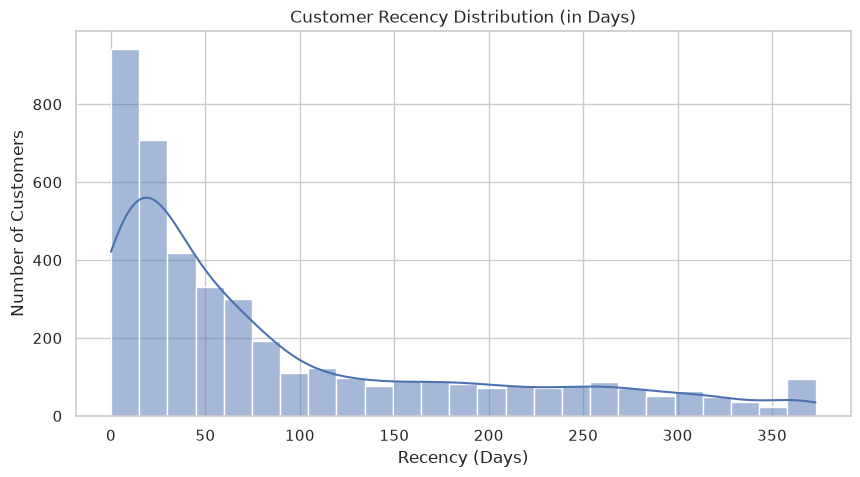

In [30]:
# Recency distribution plot
plt.figure(figsize=(10, 5))
sns.histplot(recency, kde=True)
plt.title('Customer Recency Distribution (in Days)')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.show()

### ⏱️ Customer Recency Distribution
- **Pola Kemiringan Kanan (Right-Skew):** Mayoritas pelanggan terkonsentrasi pada recency rendah (0–50 hari), menandakan basis pelanggan yang masih aktif berbelanja.
- **Ekor Panjang Dorman:** Ekor panjang hingga 300+ hari mencerminkan pelanggan yang berpotensi *churn*. Diperlukan kampanye reaktivasi berkala.

In [31]:
# Frequency calculation
frequency = df.groupby(['CustomerID'])['InvoiceNo'].count().rename('Frequency')
frequency.head()

CustomerID
12346.0      1
12347.0    182
12348.0     31
12349.0     73
12350.0     17
Name: Frequency, dtype: int64

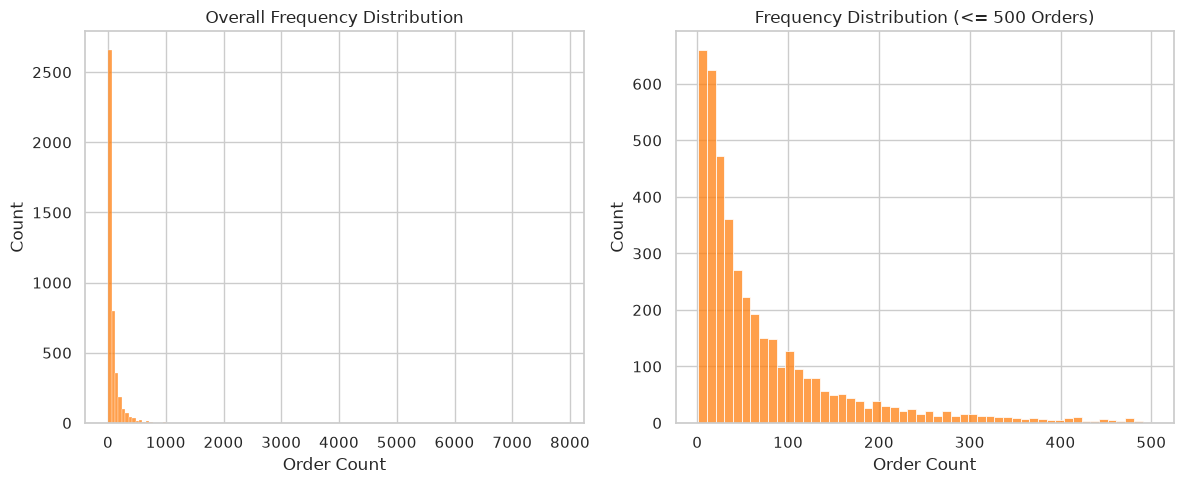

In [32]:
# Dual histogram distribution: Overall vs Zoomed (<= 500 orders)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(frequency, ax=axs[0], color='tab:orange')
sns.histplot(frequency[frequency <= 500], ax=axs[1], color='tab:orange')
axs[0].set_title('Overall Frequency Distribution')
axs[0].set_xlabel('Order Count')
axs[1].set_title('Frequency Distribution (<= 500 Orders)')
axs[1].set_xlabel('Order Count')
plt.tight_layout()
plt.show()

In [68]:
frequency.describe()

count    4338.000000
mean       91.720609
std       228.785094
min         1.000000
25%        17.000000
50%        41.000000
75%       100.000000
max      7847.000000
Name: Frequency, dtype: float64

### 🔄 Customer Frequency Distribution
- Terdapat 4.338 transaksi berbelanja, di mana mayoritas melakukan pembelian di bawah 100 pembelian.
- **Akun Komersial Ekstrem:** Sebagian kecil akun melakukan ratusan hingga ribuan pembelian (hingga 7.847 order). Akun ini merupakan entitas bisnis/grosir (*wholesalers*).

In [33]:
# Monetary calculation
monetary = df.groupby(['CustomerID'])['TotalAmount'].sum().rename('Monetary')
monetary.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Monetary, dtype: float64

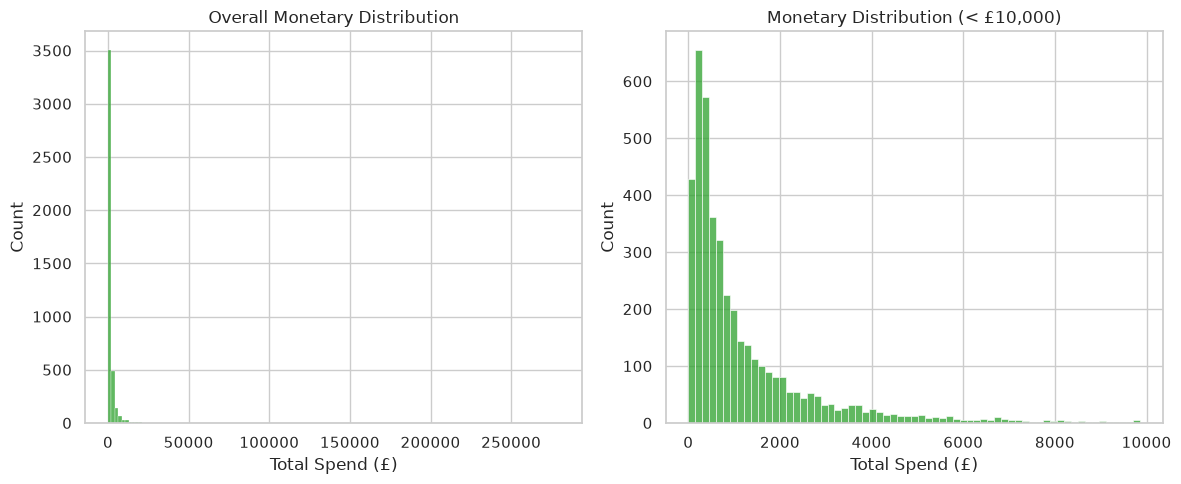

In [34]:
# Dual histogram distribution: Overall vs Zoomed (< £10,000)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(monetary, ax=axs[0], color='tab:green')
sns.histplot(monetary[monetary < 10000], ax=axs[1], color='tab:green')
axs[0].set_title('Overall Monetary Distribution')
axs[0].set_xlabel('Total Spend (£)')
axs[1].set_title('Monetary Distribution (< £10,000)')
axs[1].set_xlabel('Total Spend (£)')
plt.tight_layout()
plt.show()

In [67]:
monetary.describe()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: Monetary, dtype: float64

### 💰 Customer Monetary Value Distribution
- **Konsentrasi Pengeluaran Ritel:** Mayoritas belanja pelanggan berada di bawah **£2.000**, dengan median belanja di sekitar **£675 (£674,49)** dan rata-rata pengeluaran sebesar **£2.054,27**.
- **Akun Whale Bernilai Raksasa:** Terdapat sejumlah kecil pelanggan komersial dengan total belanja mencapai puluhan hingga ratusan ribu poundsterling (£200.000+).

### Penggabungan Dataframe & Pemisahan Peran Fitur vs Metadata


In [35]:
# Gabungkan metrik RFM dan metadata demografi ke dalam df_new
country = (
    df.groupby(['CustomerID', 'Country_isUK'])
    .size()
    .reset_index()
    .drop(0, axis=1)
)

df_new = (
    country
    .merge(recency, on='CustomerID')
    .merge(frequency, on='CustomerID')
    .merge(monetary, on='CustomerID')
    .set_index('CustomerID')
)

# Matriks fitur modeling murni 3 dimensi RFM
features = ['Recency', 'Frequency', 'Monetary']
df_rfm = df_new[features]
df_rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


### 🛡️ Penanganan Outlier (Two-Tier Segmentation) & Standarisasi Fitur

Sebelum pemodelan K-Means, dilakukan dua persiapan data utama:

1. **Two-Tier Customer Segmentation (Penanganan Outlier):**
   - **Tantangan:** Akun grosir/B2B bernilai raksasa dapat mendistorsi posisi *centroid* K-Means berbasis jarak Euclidean. Namun, akun ini tidak boleh dihapus karena merupakan kontributor pendapatan terbesar.
   - **Solusi:** 
     - **Tier 1 (Outliers — B2B Whales):** 5% akun anomali diisolasi dengan **Isolation Forest** untuk strategi bisnis khusus (*Key Account Management*).
     - **Tier 2 (Inliers — Core Retail):** 95% pelanggan ritel reguler dialirkan ke pemodelan K-Means agar klaster terbentuk alami dan proporsional.

2. **Standarisasi Fitur (`StandardScaler`):**
   - **Tantangan:** Rentang nilai antar-fitur RFM sangat timpang (*Monetary* bernilai ribuan £ vs *Recency*/*Frequency* puluhan/ratusan). Tanpa scaling, dimensi moneter akan mendominasi jarak Euclidean.
   - **Solusi:** Ditransformasikan ke skala baku Z-Score ($\mu=0, \sigma=1$) agar ketiga dimensi RFM memiliki bobot yang seimbang.

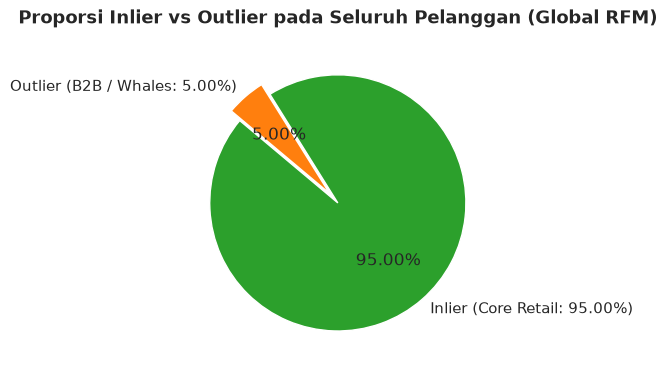

Tier 1 (B2B / Whales Outliers): 217 pelanggan (5.00%)
Tier 2 (Core Retail Inliers)  : 4,121 pelanggan (95.00%)


In [36]:
# Isolasi outlier transaksi menggunakan Isolation Forest pada seluruh data pelanggan (Two-Tier Segmentation)
model_if = IsolationForest(contamination=0.05, random_state=42)
df_new['Outlier_Scores'] = model_if.fit_predict(df_new[features].to_numpy())
df_new['Is_Outlier'] = np.where(df_new['Outlier_Scores'] == -1, 1, 0)

outlier_counts = df_new['Is_Outlier'].value_counts().sort_index()

# Visualisasi Proporsi Inlier vs Outlier pada Seluruh Pelanggan (Pie Chart)
plot_pie_chart(
    data=outlier_counts,
    title='Proporsi Inlier vs Outlier pada Seluruh Pelanggan (Global RFM)',
    labels=['Inlier (Core Retail: 95.00%)', 'Outlier (B2B / Whales: 5.00%)'],
    autopct='%1.2f%%',
    startangle=140,
    colors=['#2ca02c', '#ff7f0e'],
    explode=(0, 0.1)
)

# Pemisahan dataset ke dalam Two-Tier Segmentation
df_outliers = df_new[df_new['Is_Outlier'] == 1].copy()
df_inliers = df_new[df_new['Is_Outlier'] == 0].drop(columns=['Outlier_Scores', 'Is_Outlier']).copy()

print(f"Tier 1 (B2B / Whales Outliers): {df_outliers.shape[0]:,} pelanggan ({df_outliers.shape[0]/len(df_new)*100:.2f}%)")
print(f"Tier 2 (Core Retail Inliers)  : {df_inliers.shape[0]:,} pelanggan ({df_inliers.shape[0]/len(df_new)*100:.2f}%)")

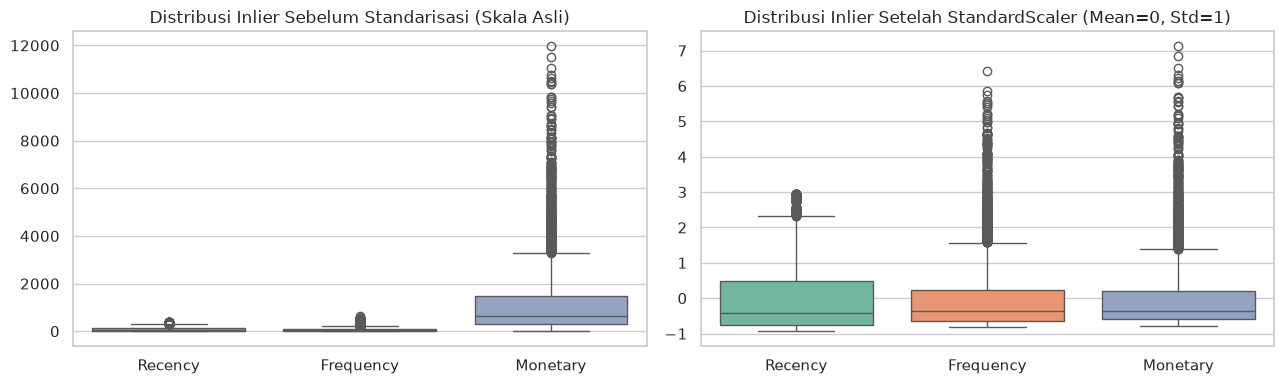

In [37]:
# Standarisasi fitur pada pelanggan ritel inti (Inliers)
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_inliers[features]),
    columns=features,
    index=df_inliers.index
)

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df_inliers[features], ax=axs[0], palette='Set2')
axs[0].set_title('Distribusi Inlier Sebelum Standarisasi (Skala Asli)')

sns.boxplot(data=df_scaled, ax=axs[1], palette='Set2')
axs[1].set_title('Distribusi Inlier Setelah StandardScaler (Mean=0, Std=1)')
plt.tight_layout()
plt.show()

### ⚖️ Evaluasi Hasil Pemisahan Two-Tier & Standarisasi Fitur
- **Isolasi Akun Ekstrem Berhasil:** Sebanyak **217 pelanggan (5,00%)** yang teridentifikasi memiliki volume dan nilai belanja anomali berhasil dipisahkan ke Tier 1 (B2B / Mega Whales) sehingga tidak lagi menjadi *leverage* destruktif bagi algoritma K-Means.
- **Distribusi Inlier Sehat:** Sebanyak **4.121 pelanggan ritel reguler (95,00%)** kini memiliki sebaran yang stabil tanpa adanya distorsi jarak bernilai puluhan hingga ratusan ribu pound sterling.
- **Skala Standar Terpadu:** Melalui `StandardScaler`, dimensi *Recency*, *Frequency*, dan *Monetary* kini memiliki kontribusi bobot yang seimbang pada ruang Euclidean ($\mu = 0, \sigma = 1$), terbukti dari visualisasi boxplot pasca-standarisasi yang simetris dan terkontrol.

## 4. Pemodelan Klaster Retail Core (K-Means Clustering)

Pada tahap ini, algoritma K-Means diterapkan pada fitur `df_scaled` (4.121 pelanggan ritel inti). Evaluasi jumlah klaster optimal ($k$) dilakukan secara kuantitatif menggunakan **Elbow Method (Inertia WCSS)** dan **Silhouette Score Method**.

In [38]:
def elbow_method(model, dataset, range_k):
    scores = []
    for k in range_k:
        model.set_params(n_clusters=k, random_state=42)
        model.fit(dataset)
        scores.append(model.inertia_)

    plot_line_chart(
        x=range_k,
        y=scores,
        title='Elbow Method (WCSS Inertia)',
        xlabel='Number of Clusters (k)',
        ylabel='Inertia',
        add_labels= True,
        fmt=',.2f',
        figsize=(8, 4)
    )

def silhouette_score_method(model, dataset, range_k):
    scores = []
    for k in range_k:
        model.set_params(n_clusters=k, random_state=42)
        model.fit(dataset)
        scores.append(silhouette_score(dataset, model.labels_))

    plot_line_chart(
        x=range_k,
        y=scores,
        title='Silhouette Score Method',
        xlabel='Number of Clusters (k)',
        ylabel='Silhouette Score',
        add_labels= True,
        fmt=',.2f',
        figsize=(8, 4)
    )

def plot_3d_clusters(data, cluster_col='cluster', title='3D Customer Segmentation (RFM Analysis)'):
    df_plot = data.copy()
    df_plot[cluster_col] = df_plot[cluster_col].astype(str)
    
    fig = px.scatter_3d(
        df_plot,
        x='Recency',
        y='Frequency',
        z='Monetary',
        color=cluster_col,
        title=title,
        opacity=0.7,
        labels={
            'Recency': 'Recency (Days)',
            'Frequency': 'Frequency (Orders)',
            'Monetary': 'Monetary (£)',
            cluster_col: 'Cluster'
        },
        color_discrete_sequence=px.colors.qualitative.G10
    )
    fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
    fig.show()
    return fig

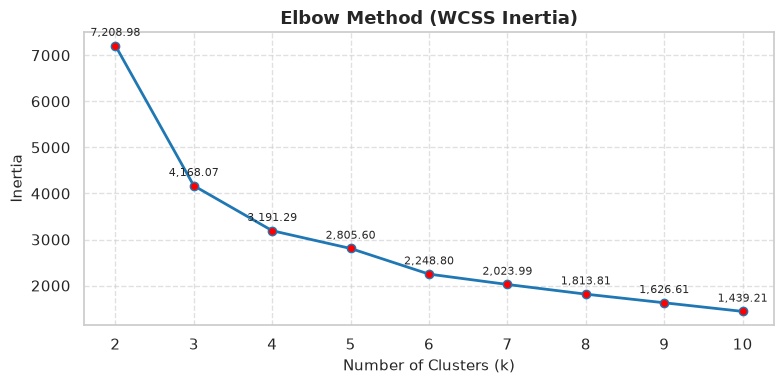

In [39]:
elbow_method(KMeans(), df_scaled, range(2, 11))

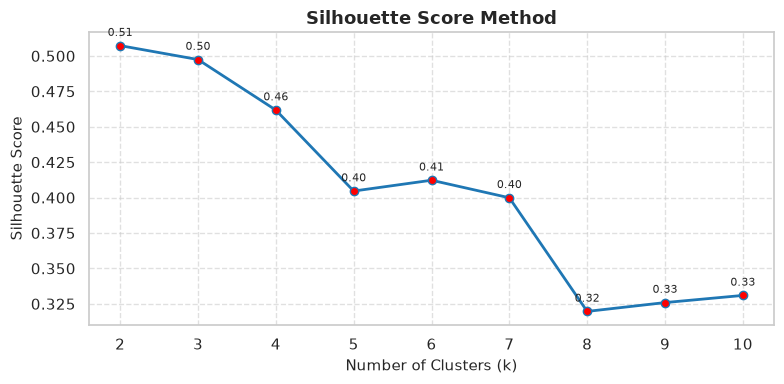

In [40]:
silhouette_score_method(KMeans(), df_scaled, range(2, 11))

### 🔍 Optimal Cluster ($k$) Selection
- **Elbow Point:** Penurunan inersia (*within-cluster sum of squares*) melandai secara jelas pada **$k = 3$**, menandakan titik siku optimal di mana penambahan klaster berikutnya menghasilkan *diminishing marginal returns*.
- **Silhouette Score Solid (~0,5):** Nilai *Silhouette Score* pada $k = 3$ mencapai **0,5**, yang mencerminkan pemisahan klaster yang sangat kohesif, padat di dalam klaster (*compact*), dan terpisah tegas antar-klaster.
- **Relevansi Persona Bisnis:** Konfigurasi $k = 3$ pada data inlier secara alami mengelompokkan pelanggan ritel ke dalam 3 spektrum perilaku yang *actionable*: *Active Core Regulars*, *At-Risk/Churned Customers*, dan *High-Value Loyal Champions*.

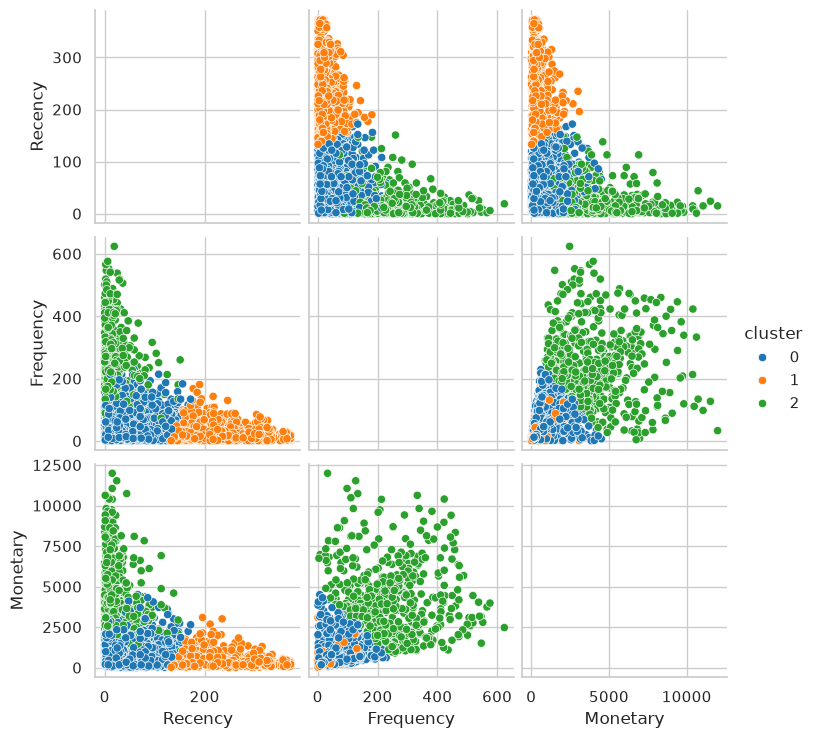

In [41]:
# Fit model K-Means k=3 & visualisasi pairplot
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(df_scaled)
df_result_kmeans = df_inliers.copy()
df_result_kmeans['cluster'] = kmeans.labels_

sns.pairplot(
    data=df_result_kmeans[features + ['cluster']],
    hue='cluster',
    diag_kind='None',
    palette='tab10'
)
plt.show()

In [42]:
# Visualisasi 3D Interaktif RFM Clusters pada Retail Core
fig_3d = plot_3d_clusters(
    data=df_result_kmeans,
    title='3D Customer Segmentation Space (Inlier Core Retail - K-Means k=3)'
)

### 🌐 Sebaran Klaster Retail Core
* **Bebas Distorsi Outlier:** Pada visualisasi pairplot dan 3D scatter, ketiga klaster terdistribusi secara seimbang dan mengisi ruang fitur RFM secara proporsional tanpa ada titik tunggal yang menyendiri di pojok ekstrem.
* **Tiga Profil Ritel yang Homogen:**
  1. **Klaster 0 (Active Core Regulars):** Basis pelanggan terbesar yang aktif bertransaksi dengan frekuensi dan pengeluaran moderat.
  2. **Klaster 1 (At-Risk / Churned):** Pelanggan pasif dengan angka *recency* tinggi yang membutuhkan kampanye reaktivasi (*win-back*).
  3. **Klaster 2 (High-Value Champions):** Pelanggan ritel terbaik dengan frekuensi transaksi tinggi dan total belanja tertinggi di antara pelanggan ritel.

In [43]:
# Fungsi kuantil dan ringkasan statistik per klaster
def q25(x):
    return x.quantile(0.25)

def q75(x):
    return x.quantile(0.75)

# Ringkasan statistik per klaster Tier 2 (Core Retail)
df_result_kmeans_desc = (
    df_result_kmeans[features + ['cluster']]
    .groupby('cluster')
    .aggregate(['mean', 'std', 'min', q25, 'median', q75, 'max'])
    .T
)
print("=== RINGKASAN STATISTIK TIER 2: KLASTER RETAIL INLIERS (k=3) ===")
display(df_result_kmeans_desc)

# Ringkasan statistik Tier 1 (B2B / Whales Outliers)
df_outliers_desc = (
    df_outliers[features]
    .aggregate(['count', 'mean', 'std', 'min', q25, 'median', q75, 'max'])
    .T
)
print("\n=== RINGKASAN STATISTIK TIER 1: B2B / VIP WHALES OUTLIERS ===")
display(df_outliers_desc)

=== RINGKASAN STATISTIK TIER 2: KLASTER RETAIL INLIERS (k=3) ===


cluster                     0            1             2
Recency   mean      45.958399   240.952764     22.484429
          std       36.605686    63.458939     25.378055
          min        0.000000   132.000000      0.000000
          q25       17.000000   186.000000      4.000000
          median    36.000000   238.000000     15.000000
          q75       70.000000   287.000000     30.000000
          max      172.000000   373.000000    151.000000
Frequency mean      52.961538    23.382915    233.754325
          std       42.735701    23.195935    110.609836
          min        1.000000     1.000000      4.000000
          q25       20.000000     8.000000    155.250000
          median    41.000000    17.000000    215.000000
          q75       77.000000    29.000000    295.750000
          max      229.000000   181.000000    624.000000
Monetary  mean     884.450653   394.967075   4043.297682
          std      712.367460   363.549410   2039.604061
          min        6.200000     3.750000    907.100000
          q25      341.615000   162.850000   2634.642500
          median   675.285000   302.700000   3628.135000
          q75     1246.155000   483.525000   5053.805000
          max     4507.010000  3096.000000  11990.960000


=== RINGKASAN STATISTIK TIER 1: B2B / VIP WHALES OUTLIERS ===


,count,mean,std,min,q25,median,q75,max
Recency,217.0,125.525346,153.379614,0.0,3.0,19.0,305.00,373.00
Frequency,217.0,481.852535,864.958994,1.0,69.0,250.0,585.00,7847.00
Monetary,217.0,18100.503876,36148.225421,15.0,1660.9,7374.9,16587.09,280206.02


In [44]:
# Verifikasi Distribusi Geografis Antar-Klaster (UK vs Non-UK)
crosstab_country = pd.crosstab(
    df_result_kmeans['cluster'], 
    df_result_kmeans['Country_isUK'], 
    rownames=['Cluster'], 
    colnames=['Origin'],
    margins=True
)
crosstab_country

Origin,Non UK,UK,All
Cluster,,,
0,231,2317,2548
1,84,911,995
2,73,505,578
All,388,3733,4121


## 5. Analisis Lanjutan & Jawaban Pertanyaan Bisnis (*Assessment Questions*)

Bagian ini menjawab secara terstruktur 3 pertanyaan bisnis utama dalam proyek ini:
* **Question 1:** Analisis Eksploratif Mendalam (Top 5 Pelanggan & Pola Waktu Pembelian).
* **Question 2:** Profil Karakteristik Segmen Two-Tier (B2B Whales & 3 Klaster Ritel Inti) & Rekomendasi Promosi.
* **Question 3:** Segmentasi Khusus Pelanggan Non-UK dengan Two-Tier Architecture & K-Means $k=4$.

### 📌 Question 1: Analisis EDA Mendalam

#### 1a) Siapa Top 5 Customer dengan Pembelian Terbanyak?

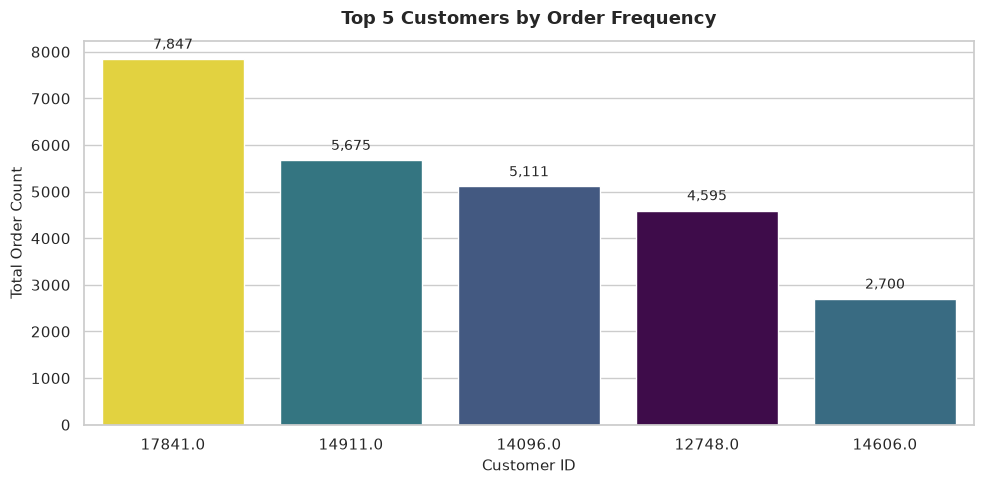

<Axes: title={'center': 'Top 5 Customers by Order Frequency'}, xlabel='Customer ID', ylabel='Total Order Count'>

In [45]:
# Top 5 Customers by purchase frequency
top_5_frequency = frequency.sort_values(ascending=False).head().reset_index()
top_5_frequency = top_5_frequency.rename(columns={'index': 'CustomerID', 'Frequency': 'Count'})

plot_bar_chart(
    data=top_5_frequency,
    x='CustomerID',
    y='Count',
    title='Top 5 Customers by Order Frequency',
    xlabel='Customer ID',
    ylabel='Total Order Count',
    palette='viridis',
    order=top_5_frequency.sort_values('Count', ascending=False)['CustomerID']
)

### 🏆 Top 5 Customers by Order Frequency
- **Leaderboard:** Pelanggan dengan ID **`17841`** memimpin dengan **7.847 transaksi**, diikuti oleh **`14911`** (5.675), **`14096`** (5.111), **`12748`** (4.595), dan **`14606`** (2.700).
- **Akun Bisnis/Reseller:** Volume transaksi yang masif ini menandakan akun-akun tersebut adalah pengecer (*reseller*), distributor, atau akun otomatis B2B yang membutuhkan perlakuan khusus (*Key Account Management*).

#### 1b) Kapan Waktu Pembelian dengan Jumlah Customer Terbanyak?

In [46]:
# Ekstraksi fitur waktu transaksi
df['year'] = df['InvoiceDate'].dt.year
df['month_name'] = df['InvoiceDate'].dt.month_name()
df['day_name'] = df['InvoiceDate'].dt.day_name()
df['hour'] = df['InvoiceDate'].dt.hour

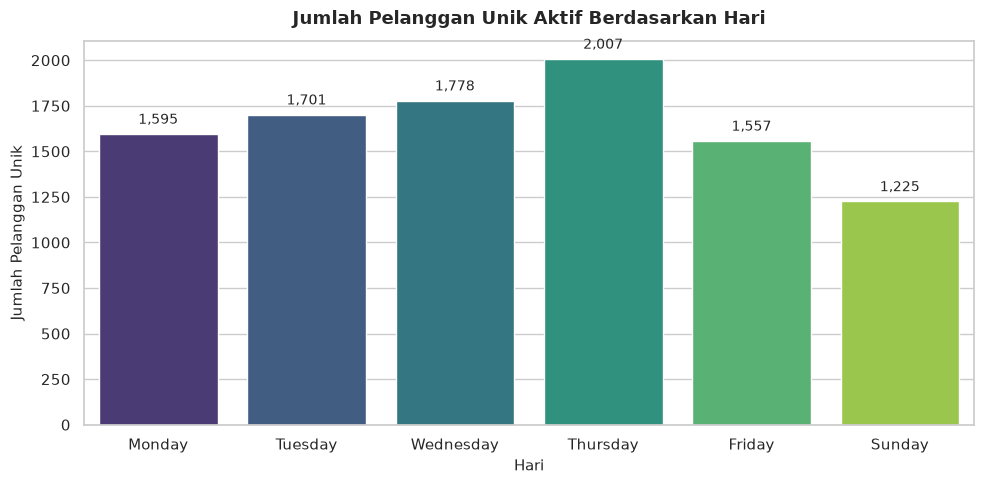

<Axes: title={'center': 'Jumlah Pelanggan Unik Aktif Berdasarkan Hari'}, xlabel='Hari', ylabel='Jumlah Pelanggan Unik'>

In [47]:
# Aktivitas pelanggan per hari dalam seminggu
daily_cust = df.groupby('day_name')['CustomerID'].nunique().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday','Sunday']).reset_index()

plot_bar_chart(
    data=daily_cust,
    x='day_name',
    y='CustomerID',
    title='Jumlah Pelanggan Unik Aktif Berdasarkan Hari',
    xlabel='Hari',
    ylabel='Jumlah Pelanggan Unik',
    palette='viridis'
)

### 📆 Customer Activity by Day of Week
- **Puncak di Hari Kerja (Kamis):** **Kamis** mencatat aktivitas pelanggan tertinggi (**2.007 pelanggan unik**), diikuti Rabu (**1.778**), Selasa (**1.701**), Senin (**1.595**), dan Jumat (**1.557**).
- **Penurunan di Akhir Pekan:** Sabtu tidak memiliki catatan transaksi (toko libur operasional), dan Minggu mencatat **1.225 pelanggan unik**.

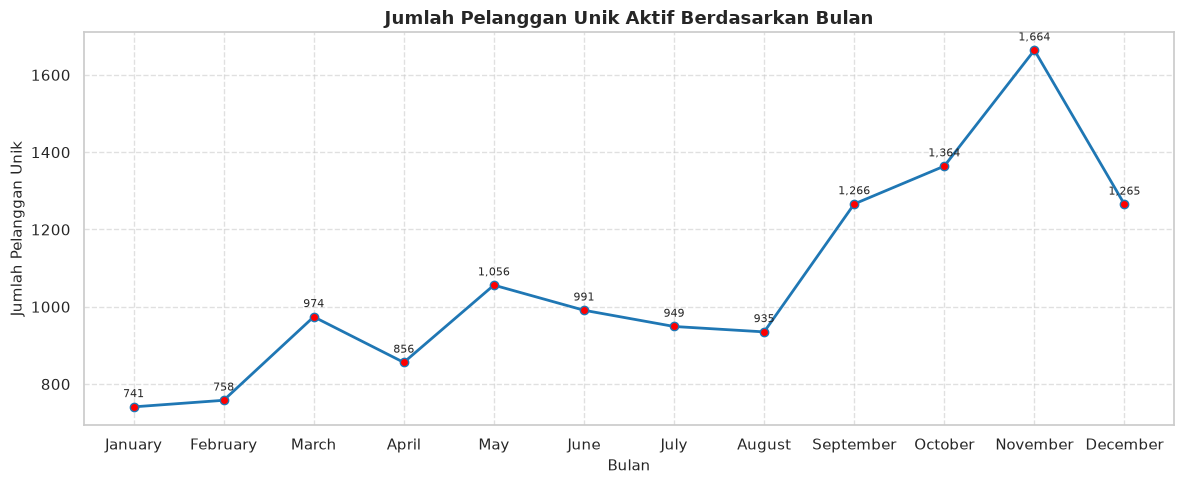

<Axes: title={'center': 'Jumlah Pelanggan Unik Aktif Berdasarkan Bulan'}, xlabel='Bulan', ylabel='Jumlah Pelanggan Unik'>

In [48]:
# Aktivitas pelanggan per bulan
monthly_cust = df.groupby('month_name')['CustomerID'].nunique().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
).reset_index()


plot_line_chart(
    x= monthly_cust['month_name'], 
    y=monthly_cust['CustomerID'], 
    title='Jumlah Pelanggan Unik Aktif Berdasarkan Bulan', 
    xlabel='Bulan', 
    ylabel='Jumlah Pelanggan Unik', 
    marker_color='red', 
    line_color='tab:blue', 
    add_labels=True, 
    fmt=',.0f'
)

### 🗓️ Customer Activity by Month
- **Lonjakan Dramatis di November:** Pelanggan aktif mencapai puncaknya di bulan **November (1.664 pelanggan unik)**, melonjak tajam dibanding rata-rata bulanan awal tahun (~750–900 pelanggan).
- **Festival Belanja Akhir Tahun:** Lonjakan ini dipicu oleh musim belanja *pre-Christmas*, Black Friday, dan Cyber Monday.

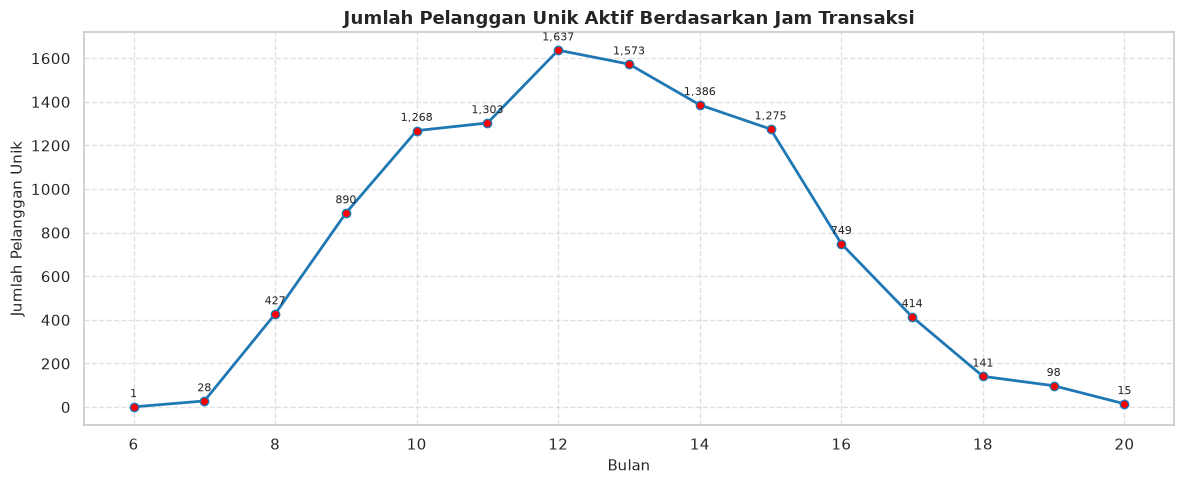

<Axes: title={'center': 'Jumlah Pelanggan Unik Aktif Berdasarkan Jam Transaksi'}, xlabel='Bulan', ylabel='Jumlah Pelanggan Unik'>

In [49]:
# Aktivitas pelanggan per jam dalam sehari
hourly_cust = df.groupby('hour')['CustomerID'].nunique().reset_index()

plot_line_chart(
    x= hourly_cust['hour'], 
    y=hourly_cust['CustomerID'], 
    title='Jumlah Pelanggan Unik Aktif Berdasarkan Jam Transaksi', 
    xlabel='Jam Transaksi (0-23)', 
    ylabel='Jumlah Pelanggan Unik', 
    marker_color='red', 
    line_color='tab:blue', 
    add_labels=True, 
    fmt=',.0f'
)

### ⏰ Customer Activity by Hour of Day
- **Jam Istirahat Siang (Peak Hours):** Aktivitas belanja meningkat signifikan sejak pukul 09:00 dan mencapai puncak tertingginya pada **pukul 12:00 (1.637 pelanggan unik)** dan **13:00 (1.573 pelanggan unik)**.
- **Strategi Flash Sale & Email Blast:** Jam 11:00–13:00 adalah waktu optimal untuk mengirimkan email penawaran, voucher kilat (*flash sale*), atau notifikasi push marketing.

---

### 📌 Question 2: Karakteristik Utama Masing-Masing Klaster & Rekomendasi Promosi

Berdasarkan strategi **Two-Tier Customer Segmentation (Opsi A)** yang memadukan isolasi segmen komersial B2B/Whales (Tier 1) dan pemodelan K-Means pada ritel inti ($k = 3$, Tier 2):

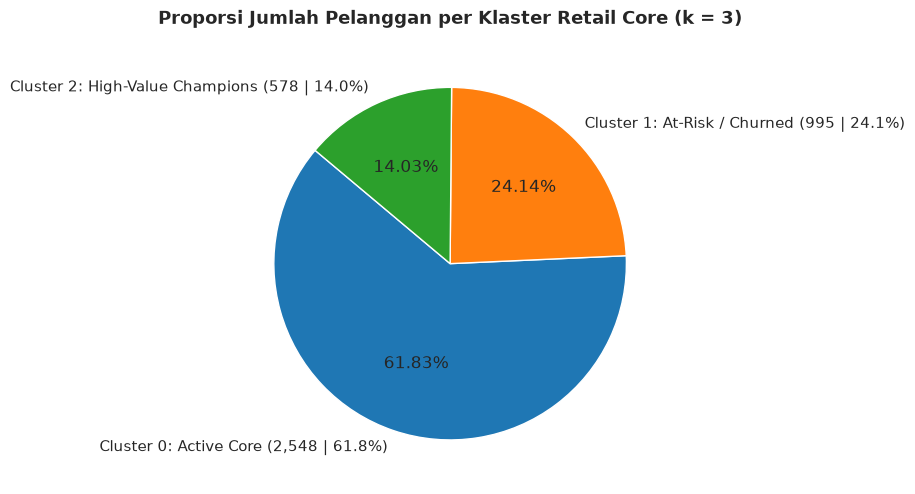

cluster                     0            1             2
Recency   mean      45.958399   240.952764     22.484429
          std       36.605686    63.458939     25.378055
          min        0.000000   132.000000      0.000000
          q25       17.000000   186.000000      4.000000
          median    36.000000   238.000000     15.000000
          q75       70.000000   287.000000     30.000000
          max      172.000000   373.000000    151.000000
Frequency mean      52.961538    23.382915    233.754325
          std       42.735701    23.195935    110.609836
          min        1.000000     1.000000      4.000000
          q25       20.000000     8.000000    155.250000
          median    41.000000    17.000000    215.000000
          q75       77.000000    29.000000    295.750000
          max      229.000000   181.000000    624.000000
Monetary  mean     884.450653   394.967075   4043.297682
          std      712.367460   363.549410   2039.604061
          min        6.200000     3.750000    907.100000
          q25      341.615000   162.850000   2634.642500
          median   675.285000   302.700000   3628.135000
          q75     1246.155000   483.525000   5053.805000
          max     4507.010000  3096.000000  11990.960000

In [64]:
# Proporsi jumlah pelanggan per klaster ritel inti (Tier 2: k = 3)
cluster_counts = df_result_kmeans['cluster'].value_counts().sort_index()

plot_pie_chart(
    data=cluster_counts,
    title='Proporsi Jumlah Pelanggan per Klaster Retail Core (k = 3)',
    labels=[
        f'Cluster 0: Active Core ({cluster_counts[0]:,} | {cluster_counts[0]/len(df_result_kmeans)*100:.1f}%)',
        f'Cluster 1: At-Risk / Churned ({cluster_counts[1]:,} | {cluster_counts[1]/len(df_result_kmeans)*100:.1f}%)',
        f'Cluster 2: High-Value Champions ({cluster_counts[2]:,} | {cluster_counts[2]/len(df_result_kmeans)*100:.1f}%)'
    ],
    autopct='%1.2f%%',
    startangle=140,
    colors=sns.color_palette('tab10'),
    figsize=(8, 7)
)

# Ringkasan statistik per klaster ritel inti
df_result_kmeans_desc

### 📊 Karakteristik Mendalam Masing-Masing Klaster & Rekomendasi Promosi

Berikut adalah analisis komprehensif profil perilaku belanja:

| Klaster / Segmen | Jumlah Pelanggan | Proporsi (% Total Pop.) | Rata-rata Recency | Rata-rata Frequency | Rata-rata Monetary | Persona Bisnis Utama |
| :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **Tier 1 (Outliers)** | 217 | 5,00% | 125,53 hari (Median: 19,0) | 481,85 order (Median: 250,0) | £18.100,50 (Median: £7.374,90) | **B2B Wholesalers & VIP Whales** |
| **Tier 2 - Cluster 0** | 2.548 | 58,74% | 45,96 hari (Median: 36,0) | 52,96 order (Median: 41,0) | £884,45 (Median: £675,29) | **Active Core Customers (Pelanggan Reguler Aktif)** |
| **Tier 2 - Cluster 1** | 995 | 22,94% | 240,95 hari (Median: 238,0) | 23,38 order (Median: 17,0) | £394,97 (Median: £302,70) | **At-Risk / Churned Customers (Pelanggan Dorman/Hilang)** |
| **Tier 2 - Cluster 2** | 578 | 13,32% | 22,48 hari (Median: 15,0) | 233,75 order (Median: 215,0) | £4.043,30 (Median: £3.628,14) | **High-Value Loyal Champions (Pelanggan Juara Ritel)** |

*(Catatan: Proporsi Tier 2 terhadap inlier adalah: Cluster 0 = 61,83%, Cluster 1 = 24,14%, Cluster 2 = 14,03%).*

---

#### 1. Tier 1 — B2B Wholesalers & VIP Whales (Akun Komersial Ekstrem)
* **Karakteristik:**
  * Terdiri dari **217 akun bisnis dan pembeli borongan volume besar** (5,00% dari total populasi) yang menyumbang porsi pendapatan masif bagi perusahaan.
  * Memiliki daya beli fantastis dengan rata-rata transaksi mencapai **£18.100,50 per akun** (maksimum mencapai **£280.206,02**) dan frekuensi hingga **7.847 pesanan**.
  * Siklus belanja bervariasi (median recency 19 hari, namun beberapa akun memiliki jeda antar-order musiman).
* **Rekomendasi Promosi & Strategi Bisnis:**
  * **Dedicated Key Account Manager:** Hubungan personal langsung melalui tim sales B2B enterprise, bukan promosi retail massal.
  * **Tiered Bulk Volume Pricing:** Skema potongan harga khusus pesanan grosir berbasis kuantitas karton/kontainer.
  * **Flexible Credit Terms:** Fasilitas pembayaran invoice bertempo (*Net 30/60 days payment terms*).
  * **Automated B2B Reordering & EDI/API:** Integrasi sistem inventaris otomatis agar pemesanan ulang bahan baku/stok berlangsung mulus.

---

#### 2. Tier 2 - Cluster 0 — Active Core Customers (Pelanggan Reguler Aktif)
* **Karakteristik:**
  * Mewakili kelompok mayoritas pasar ritel (**2.548 pelanggan** atau **58,7% dari seluruh basis pelanggan**).
  * Sangat sehat dan aktif bertransaksi (Recency rata-rata ~46 hari, median 36 hari).
  * Menghasilkan nilai transaksi moderat dan konsisten (rata-rata 53 pesanan dengan total belanja £884,45 / median £675,29).
* **Rekomendasi Promosi & Strategi Bisnis:**
  * **Tiered Loyalty Program:** Program reward poin belanja bertingkat untuk mendorong peningkatan frekuensi belanja berkala.
  * **Cross-Selling & Personalized Bundling:** Rekomendasi produk komplementer berbasis machine learning (*frequently bought together*) untuk menaikkan *Average Order Value* (AOV).
  * **Threshold Spending Coupons:** Voucher belanja bersyarat (misal: *"Belanja minimal £100 dapat diskon £15 untuk pesanan berikutnya"*).

---

#### 3. Tier 2 - Cluster 1 — At-Risk / Churned Customers (Pelanggan Dorman/Hilang)
* **Karakteristik:**
  * Mencakup **995 pelanggan (22,9% dari total populasi)** yang sudah tidak aktif berbelanja selama lebih dari 8 bulan (Recency rata-rata 241 hari, median 238 hari).
  * Frekuensi belanja rendah (rata-rata 23 order) dan nilai belanja terendah (rata-rata £394,97 / median £302,70).
* **Rekomendasi Promosi & Strategi Bisnis:**
  * **Automated Win-Back Email Journey:** Rangkaian email reaktivasi otomatis dengan insentif agresif (misal: *"We Miss You! Nikmati diskon 20% + Bebas Ongkir untuk pembelian Anda minggu ini"*).
  * **Customer Exit Survey:** Kuesioner kepuasan singkat untuk mengetahui alasan berhenti bertransaksi (masalah harga, pengiriman, atau katalog produk) dengan reward voucher belanja.
  * **Seasonal Catalog Campaign:** Retargeting katalog promosi saat momentum belanja besar (Black Friday, Natal, atau Summer Sale).

---

#### 4. Tier 2 - Cluster 2 — High-Value Loyal Champions (Pelanggan Juara Ritel)
* **Karakteristik:**
  * Kelompok ritel paling bernilai (**578 pelanggan** atau **13,3% dari total populasi**).
  * Sangat loyal dan paling baru bertransaksi (Recency rata-rata hanya 22,5 hari, median 15 hari).
  * Frekuensi transaksi sangat tinggi (rata-rata 234 pesanan) dengan kontribusi belanja retail tertinggi (rata-rata **£4.043,30** / median £3.628,14, maksimal £11.990).
* **Rekomendasi Promosi & Strategi Bisnis:**
  * **VIP Loyalty Fast-Track:** Status keanggotaan VIP eksklusif dengan jalur *priority customer service* dan *early access* peluncuran produk baru.
  * **Surprise & Delight Rewards:** Hadiah kejutan (*gift with purchase*) atau kartu ucapan terima kasih personal pada pesanan bernilai tinggi untuk memperkuat ikatan emosional merek (*brand affinity*).
  * **Referral Ambassador Program:** Insentif referral timbal balik untuk mengajak rekan mereka berbelanja (*"Ajak rekan Anda dan dapatkan bonus saldo belanja £25"*).

---

### 📌 Question 3: Segmentasi Khusus Pelanggan di Luar UK (Non-UK Focus)

Pada analisis eksploratif sebelumnya, pelanggan internasional (Non-UK) menyumbang sekitar 9,6% dari total basis pelanggan e-commerce. 

Pada bagian ini, kita mengisolasi subset pelanggan internasional (`Country_isUK == 'Non UK'`) sebanyak 418 pelanggan untuk mengeksekusi pipeline segmentasi khusus pasar luar negeri:
1. **Pemisahan Tingkat Pelanggan:** Mengelompokkan 418 pelanggan Non-UK ke dalam Tier 1 (Overseas B2B / Whales) dan Tier 2 (Overseas Core Retail).
2. **Pemodelan & Evaluasi Klaster:** Menjalankan pemodelan K-Means pada segmen ritel Tier 2 dan mengidentifikasi jumlah klaster optimal ($k = 4$).
3. **Analisis Profil & Strategi Bisnis Internasional:** Menginterpretasikan karakteristik belanja setiap segmen serta merumuskan rekomendasi ekspansi ekspor dan promosi lintas negara.

In [51]:
# Filter khusus pelanggan di luar UK (Non-UK)
df_new_non_uk = df_new[df_new['Country_isUK'] == 'Non UK'][features]
print(f"Total pelanggan Non-UK: {df_new_non_uk.shape[0]:,} pelanggan")
df_new_non_uk.head()

Total pelanggan Non-UK: 418 pelanggan


,Recency,Frequency,Monetary
CustomerID,,,
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40
12352.0,35,85,2506.04


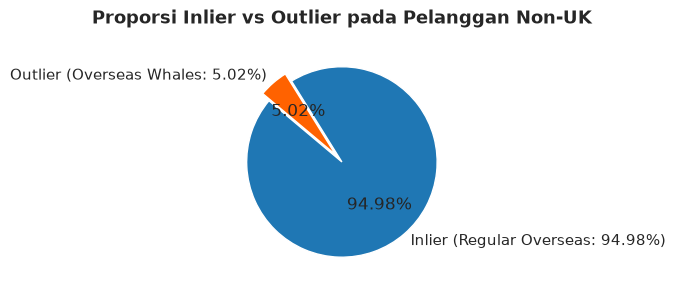

In [77]:
# Isolasi outlier transaksi Non-UK menggunakan Isolation Forest
model_if = IsolationForest(contamination=0.05, random_state=42)
df_new_non_uk['Outlier_Scores'] = model_if.fit_predict(df_new_non_uk[features].to_numpy())
df_new_non_uk['Is_Outlier'] = np.where(df_new_non_uk['Outlier_Scores'] == -1, 1, 0)

outlier_counts_non_uk = df_new_non_uk['Is_Outlier'].value_counts().sort_index()

# Visualisasi Proporsi Inlier vs Outlier Non-UK dengan Pie Chart
plot_pie_chart(
    data=outlier_counts_non_uk,
    title='Proporsi Inlier vs Outlier pada Pelanggan Non-UK',
    labels=[f'Inlier (Regular Overseas: 94.98%)', 'Outlier (Overseas Whales: 5.02%)'],
    autopct='%1.2f%%',
    startangle=140,
    colors=['#1f77b4', '#ff6200'],
    explode=(0, 0.1)
)

In [95]:
outlier_df_new_non_uk=df_new_non_uk[df_new_non_uk['Is_Outlier']==1]
inlier__df_new_non_uk=df_new_non_uk[df_new_non_uk['Is_Outlier']==0]


print('Tier 1')
display(outlier_df_new_non_uk.describe())
print('')
print('')
print('Tier 2')
display(inlier__df_new_non_uk.describe())

Tier 1


,Recency,Frequency,Monetary,Outlier_Scores,Is_Outlier
count,21.000000,21.000000,21.000000,21.0,21.0
mean,116.714286,665.333333,40931.878095,-1.0,1.0
std,147.028957,1252.430570,69608.231703,0.0,0.0
min,0.000000,2.000000,192.600000,-1.0,1.0
25%,3.000000,77.000000,3811.950000,-1.0,1.0
50%,23.000000,222.000000,13689.670000,-1.0,1.0
75%,280.000000,525.000000,21429.390000,-1.0,1.0
max,373.000000,5675.000000,280206.020000,-1.0,1.0




Tier 2


,Recency,Frequency,Monetary,Outlier_Scores,Is_Outlier
count,397.000000,397.000000,397.000000,397.0,397.0
mean,93.400504,74.536524,1872.662242,1.0,0.0
std,101.867478,82.344845,2368.003101,0.0,0.0
min,0.000000,1.000000,51.560000,1.0,0.0
25%,18.000000,21.000000,453.010000,1.0,0.0
50%,52.000000,42.000000,982.570000,1.0,0.0
75%,133.000000,97.000000,2409.900000,1.0,0.0
max,371.000000,446.000000,18895.910000,1.0,0.0


### 📊 Output Distribusi Segmen Non-UK (Tier 1 vs Tier 2)
- **Komposisi Pelanggan Internasional:**
  - **Tier 2 (Overseas Core Retail Inliers):** Sebanyak **397 pelanggan (94,98%)** berada pada kategori pembeli ritel reguler internasional.
  - **Tier 1 (Overseas B2B / Whales Outliers):** Sebanyak **21 pelanggan (5,02%)** teridentifikasi sebagai akun komersial bervolume ekstrem.
- **Profil Finansial Segmen Tier 1 Non-UK:**
  - Segmen Tier 1 Non-UK memiliki rata-rata belanja mencapai **£40.931,88 per akun** (median £13.689,67), dengan nilai transaksi ekspor tertinggi mencapai **£280.206,02** dan frekuensi hingga 5.675 pesanan.
  - Data ini menunjukkan bahwa pasar internasional memiliki konsentrasi nilai belanja yang sangat signifikan pada segelintir mitra distributor dan importir global.

In [53]:
# Pemisahan dataset Non-UK ke Tier 1 dan Tier 2
df_non_uk_outliers = df_new_non_uk[df_new_non_uk['Is_Outlier'] == 1].copy()
df_new_non_uk_cleaned = df_new_non_uk[df_new_non_uk['Is_Outlier'] == 0].drop(
    columns=['Outlier_Scores', 'Is_Outlier']
).copy()

print(f"Tier 1 Non-UK (Overseas B2B / Exporters Outliers): {df_non_uk_outliers.shape[0]} pelanggan ({df_non_uk_outliers.shape[0]/len(df_new_non_uk)*100:.2f}%)")
print(f"Tier 2 Non-UK (Overseas Core Retail Inliers)     : {df_new_non_uk_cleaned.shape[0]} pelanggan ({df_new_non_uk_cleaned.shape[0]/len(df_new_non_uk)*100:.2f}%)")

Tier 1 Non-UK (Overseas B2B / Exporters Outliers): 21 pelanggan (5.02%)
Tier 2 Non-UK (Overseas Core Retail Inliers)     : 397 pelanggan (94.98%)


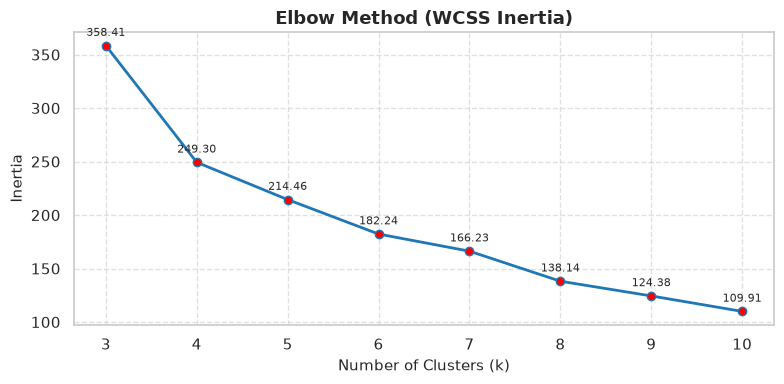

In [54]:
# Standarisasi data Non-UK bersih
scaler_non_uk = StandardScaler()
df_new_non_uk_scaled = pd.DataFrame(
    scaler_non_uk.fit_transform(df_new_non_uk_cleaned),
    columns=features,
    index=df_new_non_uk_cleaned.index
)

elbow_method(KMeans(), df_new_non_uk_scaled, range(3, 11), )

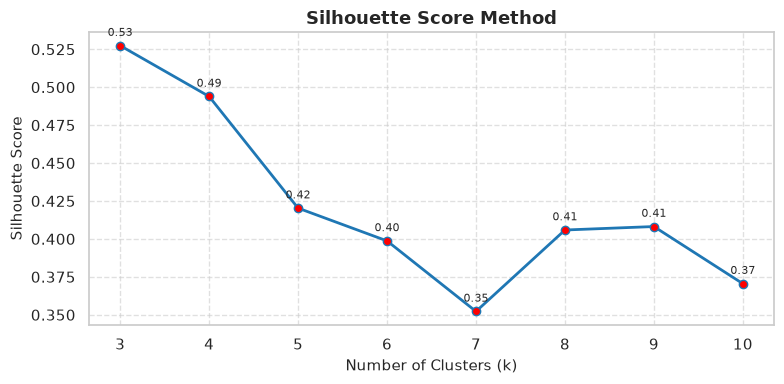

In [55]:
silhouette_score_method(KMeans(), df_new_non_uk_scaled, range(3, 11))

### 🔍 Non-UK Optimal Cluster Selection 
- **Penurunan Inersia Nyata (*True Elbow Point*):** Berdasarkan kurva Elbow (WCSS Inertia), penurunan inersia paling tajam terjadi dari $k=3$ ke $k=4$ (turun drastis lebih dari **109 poin**, dari ~358 ke ~249). Setelah $k=4$, kurva melandai secara nyata, menandakan bahwa titik siku optimal berada persis di **$k = 4$**.
- **Silhouette Score Sangat Solid (~0,494):** Pada $k=4$, nilai *Silhouette Score* sangat tinggi dan kuat (**0,49**), mengalami penurunan tajam ke **0,42** di $k=5$ dan **0,40** di $k=6$.
- **Diferensiasi Tajam 4 Persona Ritel:** Konfigurasi $k = 4$ memberikan pemisahan segmen yang jauh lebih kaya dan *actionable* dibandingkan $k = 3$, karena mampu membedakan pelanggan ritel biasa (*Regular*), pelanggan yang sedang bertumbuh loyal (*High-Potential*), pelanggan juara bervolume tinggi (*Super Champions*), serta akun pasif (*Dormant*).

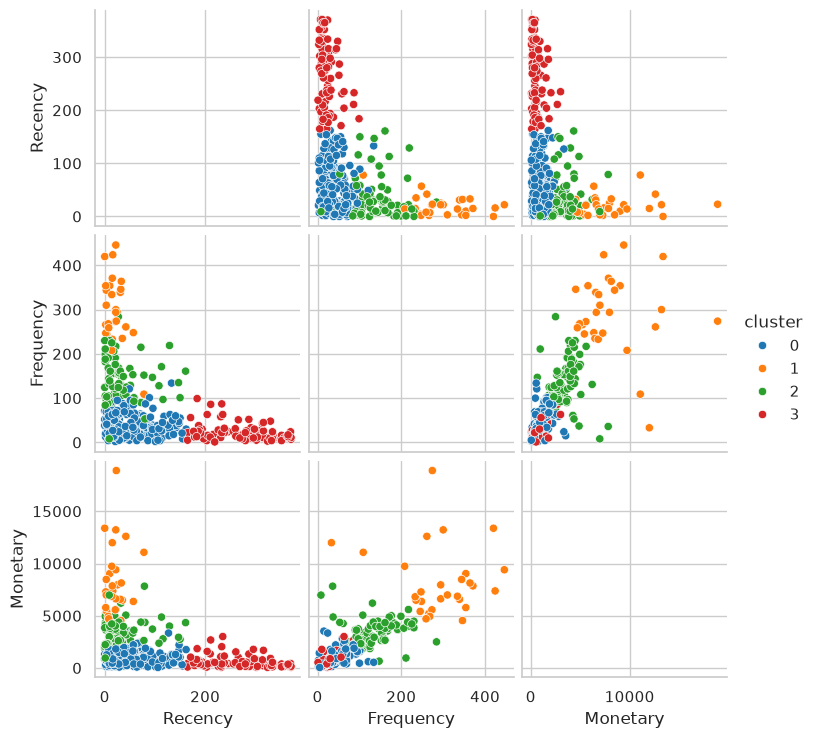

In [56]:
# Pemodelan K-Means Non-UK k=4 & Pairplot
kmeans_non_uk = KMeans(n_clusters=4, random_state=42, n_init=10).fit(df_new_non_uk_scaled)
df_non_uk_result = df_new_non_uk_cleaned.copy()
df_non_uk_result['cluster'] = kmeans_non_uk.labels_

sns.pairplot(
    data=df_non_uk_result[features + ['cluster']],
    hue='cluster',
    diag_kind='None',
    palette='tab10'
)
plt.show()

In [57]:
# Visualisasi 3D Interaktif Non-UK Customer Segmentation (k=4)
fig_3d_non_uk = plot_3d_clusters(
    data=df_non_uk_result,
    title='3D Non-UK Customer Segmentation (RFM Analysis - K-Means k=4)'
)

In [58]:
# Ringkasan statistik per klaster Tier 2 Non-UK (k=4)
df_non_uk_result_kmeans_desc = (
    df_non_uk_result[features + ['cluster']]
    .groupby('cluster')
    .aggregate(['mean', 'std', 'min', q25, 'median', q75, 'max'])
    .T
)
print("=== RINGKASAN STATISTIK TIER 2: KLASTER RETAIL NON-UK (k=4) ===")
display(df_non_uk_result_kmeans_desc)

# Ringkasan statistik Tier 1 Non-UK (Overseas B2B / Exporters Outliers)
df_non_uk_outliers_desc = (
    df_non_uk_outliers[features]
    .aggregate(['count', 'mean', 'std', 'min', q25, 'median', q75, 'max'])
    .T
)
print("\n=== RINGKASAN STATISTIK TIER 1: OVERSEAS B2B / VIP WHALES OUTLIERS ===")
display(df_non_uk_outliers_desc)

=== RINGKASAN STATISTIK TIER 2: KLASTER RETAIL NON-UK (k=4) ===


cluster                     0             1            2            3
Recency   mean      55.627451     19.758621    33.493827   270.433735
          std       42.081067     17.630443    37.559993    59.256613
          min        0.000000      0.000000     0.000000   165.000000
          q25       20.750000      7.000000     8.000000   222.500000
          median    49.500000     15.000000    21.000000   277.000000
          q75       81.000000     25.000000    37.000000   315.500000
          max      162.000000     78.000000   161.000000   371.000000
Frequency mean      40.411765    291.482759   135.320988    23.289157
          std       24.812341     86.835485    49.854495    19.280048
          min        2.000000     33.000000     8.000000     1.000000
          q25       21.000000    248.000000   101.000000    11.000000
          median    36.000000    294.000000   128.000000    18.000000
          q75       57.000000    346.000000   167.000000    26.000000
          max      134.000000    446.000000   284.000000    99.000000
Monetary  mean     879.895539   8252.634138  3406.400370   586.787952
          std      593.503243   3255.311015  1205.023585   572.758987
          min       51.560000   4541.720000   657.800000    63.000000
          q25      439.770000   6372.580000  2506.040000   222.025000
          median   750.515000   7281.380000  3338.220000   415.700000
          q75     1231.685000   9401.280000  4051.170000   630.005000
          max     3528.340000  18895.910000  7829.890000  3010.740000


=== RINGKASAN STATISTIK TIER 1: OVERSEAS B2B / VIP WHALES OUTLIERS ===


,count,mean,std,min,q25,median,q75,max
Recency,21.0,116.714286,147.028957,0.0,3.00,23.00,280.00,373.00
Frequency,21.0,665.333333,1252.430570,2.0,77.00,222.00,525.00,5675.00
Monetary,21.0,40931.878095,69608.231703,192.6,3811.95,13689.67,21429.39,280206.02


### 🌍 Karakteristik Utama Klaster Non-UK & Strategi Bisnis Internasional

Berdasarkan strategi **Two-Tier Customer Segmentation** pada 418 pelanggan internasional (21 akun B2B Tier 1 + 397 pelanggan ritel Tier 2 dengan K-Means $k=4$):

| Klaster / Segmen Non-UK | Jumlah Pelanggan | Proporsi (% Pop. Non-UK) | Rata-rata Recency | Rata-rata Frequency | Rata-rata Monetary | Persona Bisnis Internasional |
| :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **Tier 1 (Outliers)** | **21** | **5,02%** | 116,71 hari (Median: 23,0) | 665,33 order (Median: 222,0) | £40.931,88 (Median: £13.689,67) | **Overseas B2B Wholesalers & Global Exporters** |
| **Tier 2 - Cluster 0** | **204** | **48,80%** | 55,63 hari (Median: 49,5) | 40,41 order (Median: 36,0) | £879,90 (Median: £750,52) | **Regular Mid-Tier Overseas Shoppers** |
| **Tier 2 - Cluster 1** | **29** | **6,94%** | 19,76 hari (Median: 15,0) | 291,48 order (Median: 294,0) | £8.252,63 (Median: £7.281,38) | **Super Champions / Top Overseas VIPs** |
| **Tier 2 - Cluster 2** | **81** | **19,38%** | 33,49 hari (Median: 21,0) | 135,32 order (Median: 128,0) | £3.406,40 (Median: £3.338,22) | **Loyal High-Potential Shoppers** |
| **Tier 2 - Cluster 3** | **83** | **19,86%** | 270,43 hari (Median: 277,0) | 23,29 order (Median: 18,0) | £586,79 (Median: £415,70) | **Dormant / Lost Overseas Accounts** |

*(Catatan: Proporsi Tier 2 terhadap inlier Non-UK adalah: Cluster 0 = 51,39%, Cluster 1 = 7,30%, Cluster 2 = 20,40%, Cluster 3 = 20,91%).*

---

#### 1. Tier 1 — Overseas B2B Wholesalers & Global Exporters (Distributor & Grosir Ekspor)
* **Karakteristik:**
  * Terdiri dari **21 entitas bisnis internasional dan importir grosir** (5,02% dari pasar Non-UK).
  * Menghasilkan nilai penjualan ekspor fantastis dengan rata-rata belanja mencapai **£40.931,88 per akun** (median £13.689,67, dan pesanan terbesar platform mencapai **£280.206,02** dengan 5.675 transaksi).
  * Sangat aktif dan baru saja bertransaksi (median recency 23 hari).
* **Strategi Bisnis & Ekspor Internasional:**
  * **Dedicated International Export Account Manager:** Layanan representatif ekspor personal lintas zona waktu untuk menangani kontrak pasokan berkelanjutan.
  * **Incoterms & Freight Forwarding Optimization:** Dukungan pengiriman kontainer/kargo laut-udara dengan skema FOB (*Free On Board*) atau CIF (*Cost, Insurance, and Freight*) dan bantuan dokumen kepabeanan (*customs clearance / Certificate of Origin*).
  * **Multi-Currency Flexible Terms:** Fasilitas pembayaran valas bertempo melalui *Letter of Credit* (L/C) atau faktur internasional (*Net 30/60 days wire payment*).

---

#### 2. Tier 2 - Cluster 0 — Regular Mid-Tier Overseas Shoppers (Pelanggan Internasional Reguler)
* **Karakteristik:**
  * Mewakili basis pasar ritel terbesar di luar negeri (**204 pelanggan / 48,8% dari total Non-UK**).
  * Memiliki ritme belanja moderat yang stabil (Recency rata-rata ~56 hari, median 49,5 hari).
  * Rata-rata transaksi 40 pesanan dengan nilai belanja sekitar **£879,90** (median £750,52).
* **Strategi Promosi Internasional:**
  * **Loyalty Points Multiplier:** Poin loyalitas ganda (*2x points*) untuk transaksi lintas negara guna mengompensasi jeda waktu pengiriman logistik internasional.
  * **Smart Shipping Bundles:** Rekomendasi paket hemat logistik (produk dengan dimensi efisien) agar pelanggan dapat memaksimalkan batas bobot ongkos kirim flat internasional.

---

#### 3. Tier 2 - Cluster 1 — Super Champions / Top Overseas VIPs (Pelanggan Juara Super VIP Luar Negeri)
* **Karakteristik:**
  * Segmen ritel internasional paling prestisius (**29 pelanggan / 6,9% dari total Non-UK**).
  * Sangat loyal dan baru saja berbelanja (Recency rata-rata hanya ~20 hari, median 15 hari).
  * Frekuensi belanja tertinggi (rata-rata 291 order, median 294) dengan nilai belanja ritel fantastis rata-rata **£8.252,63 per pelanggan** (maksimal mencapai **£18.895,91**).
* **Strategi Promosi Internasional:**
  * **Free International Express Shipping:** Pengiriman kilat internasional gratis tanpa syarat minimum belanja sebagai apresiasi keanggotaan kasta tertinggi.
  * **VIP Concierge & Early Access:** Akses eksklusif rilisan produk baru lebih awal dan layanan concierge multibahasa via direct messaging/WhatsApp.
  * **Luxury British Gift with Purchase:** Hadiah fisik premium khas manufaktur Inggris pada setiap order bernilai tinggi untuk memperkokoh loyalitas emosional.

---

#### 4. Tier 2 - Cluster 2 — Loyal High-Potential Shoppers (Pelanggan Setia Potensial Bertumbuh)
* **Karakteristik:**
  * Segmen pembeli setia bernilai tinggi yang sedang berkembang (**81 pelanggan / 19,4% dari total Non-UK**).
  * Baru bertransaksi (Recency rata-rata ~33 hari, median 21 hari).
  * Frekuensi dan nilai belanja sangat solid (rata-rata 135 pesanan dengan total belanja **£3.406,40**).
* **Strategi Promosi Internasional:**
  * **Tier Upgrade Challenge:** Dorongan insentif belanja berhadiah untuk menaikkan status mereka ke kasta Super Champions (misal: *"Belanja £500 lagi bulan ini untuk membuka status VIP Free Shipping"*).
  * **Category Cross-Selling:** Rekomendasi kategori produk baru bernilai tinggi berdasarkan katalog riwayat transaksi mereka sebelumnya.

---

#### 5. Tier 2 - Cluster 3 — Dormant / Lost Overseas Accounts (Pelanggan Internasional Dorman)
* **Karakteristik:**
  * Mencakup **83 pelanggan luar negeri (19,9% dari total Non-UK)** yang telah tidak berbelanja selama sekitar 9 bulan (Recency rata-rata 270 hari, median 277 hari).
  * Frekuensi dan nilai belanja awal relatif rendah (rata-rata 23 order dan belanja £586,79 / median £415,70).
* **Strategi Promosi Internasional:**
  * **Global Win-Back Campaign:** Kampanye email otomatis terstruktur dengan diskon pengiriman internasional agresif saat musim clearance (Black Friday / Boxing Day).
  * **Ad Spend Suppression:** Jika tidak merespons setelah 2 kali kampanye reaktivasi, hentikan penargetan iklan berbayar (*paid ads suppression*) untuk menjaga efisiensi anggaran pemasaran internasional.